Original Shape: (95837, 23)

Column Names:
Index(['id_songs', 'name_song', 'popularity_songs', 'duration_ms', 'explicit',
       'id_artists', 'release_date', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'time_signature', 'followers', 'genres',
       'name_artists', 'popularity_artists'],
      dtype='object')

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95837 entries, 0 to 95836
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_songs            95837 non-null  object 
 1   name_song           95837 non-null  object 
 2   popularity_songs    95837 non-null  int64  
 3   duration_ms         95837 non-null  int64  
 4   explicit            95837 non-null  int64  
 5   id_artists          95837 non-null  object 
 6   release_date        95837 non-null  object 
 7   danceability   

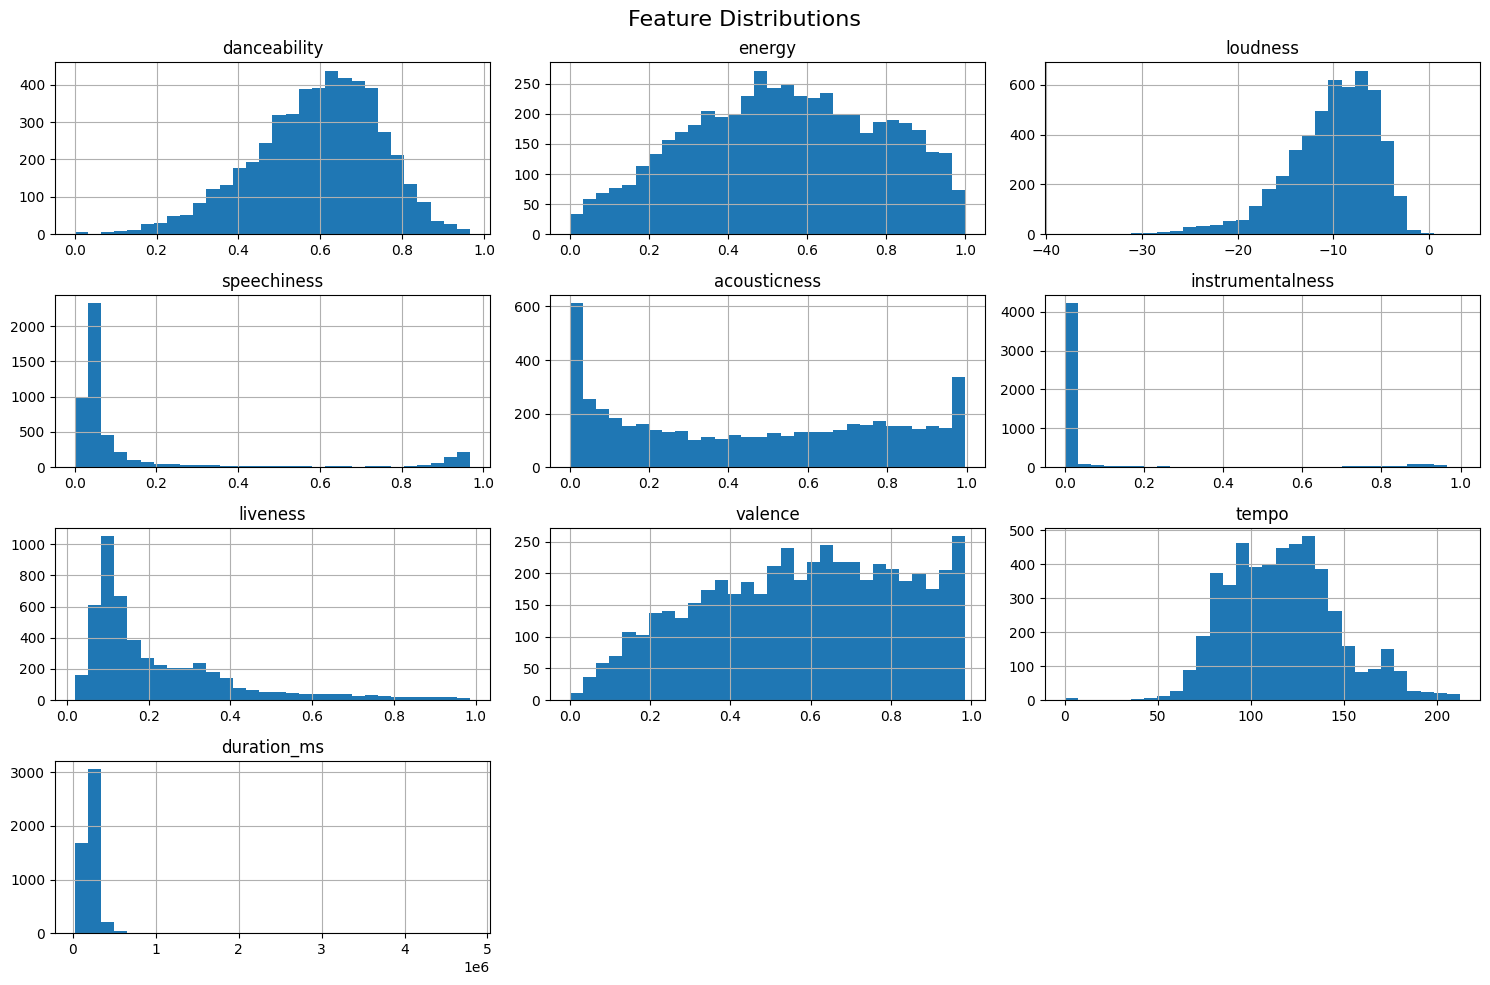

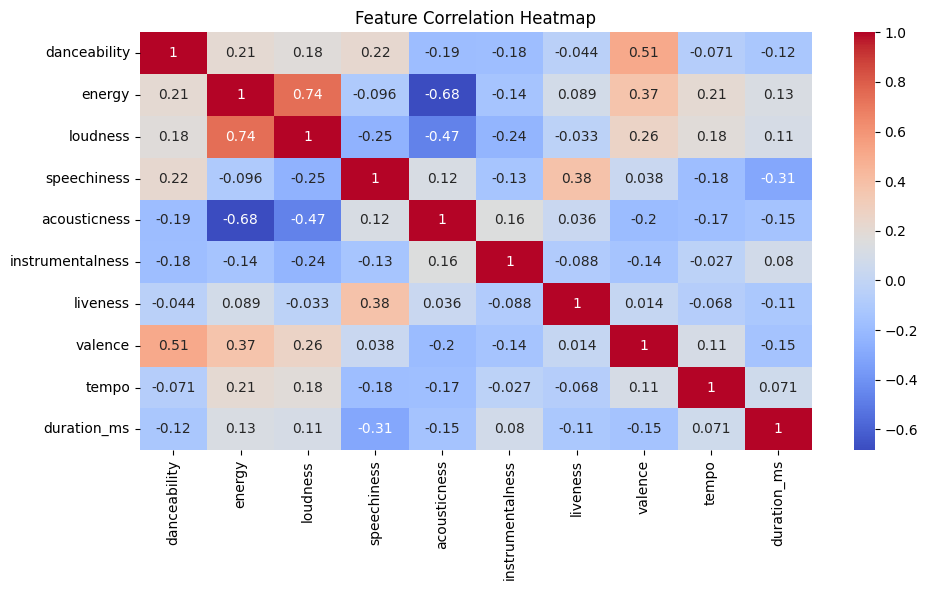


Scaling completed successfully.


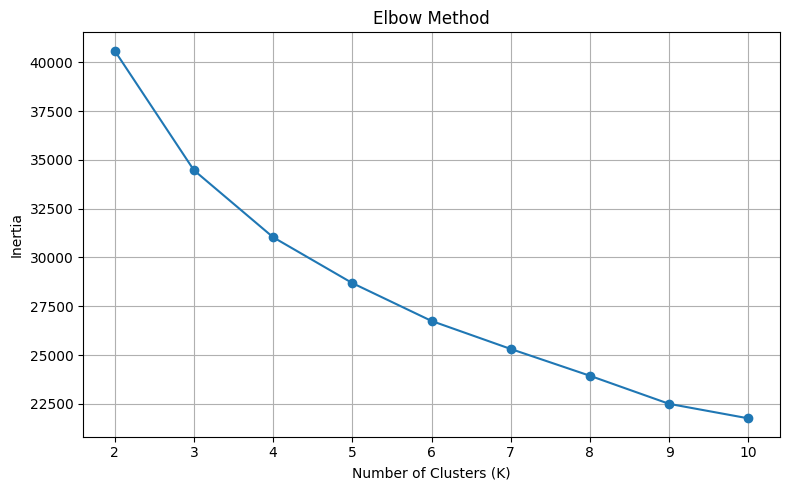

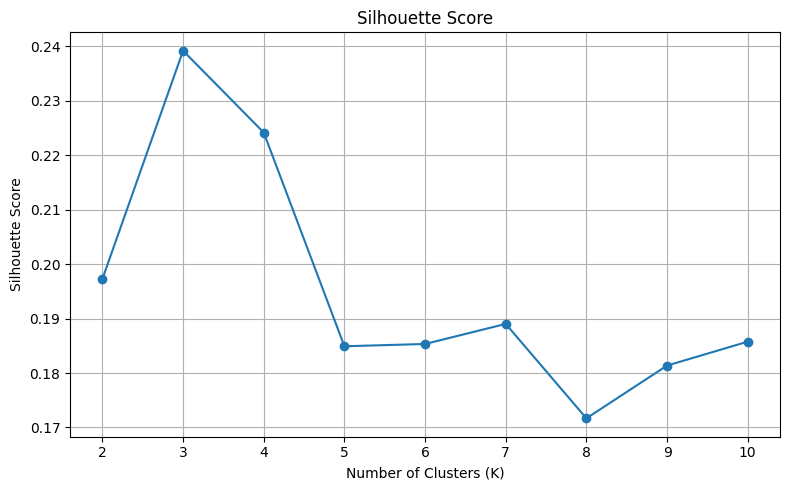


Silhouette Scores:
K=2: 0.19728409118929005
K=3: 0.23918104942101248
K=4: 0.2241543850991024
K=5: 0.18490778279629974
K=6: 0.1853334997645651
K=7: 0.18901577016152699
K=8: 0.17167701956930964
K=9: 0.18136965311224554
K=10: 0.18575863657212416

Cluster Counts:
Cluster
0    2379
1     600
2     437
3    1584
Name: count, dtype: int64

Final Model Evaluation:
Silhouette Score: 0.2241543850991024
Davies-Bouldin Score: 1.5191606285791113


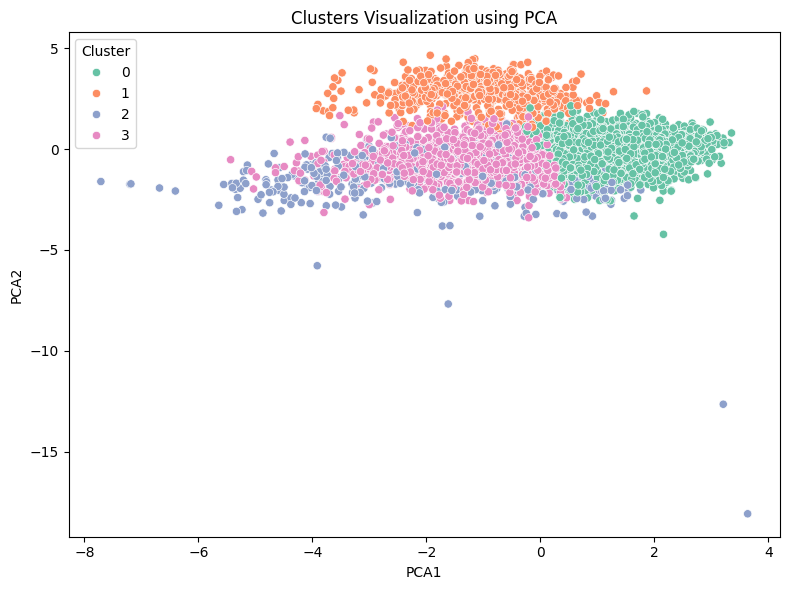


Cluster Summary:
         danceability    energy   loudness  speechiness  acousticness  \
Cluster                                                                 
0            0.640734  0.714944  -7.349090     0.076184      0.237370   
1            0.667293  0.463483 -13.442385     0.840587      0.583607   
2            0.499554  0.428607 -13.652011     0.059359      0.634410   
3            0.510985  0.348857 -12.038873     0.056471      0.695976   

         instrumentalness  liveness   valence       tempo    duration_ms  
Cluster                                                                   
0                0.017320  0.206668  0.696814  124.635248  224282.165616  
1                0.002694  0.433498  0.591452  101.104315   95124.865000  
2                0.811657  0.178668  0.458182  114.325799  245738.883295  
3                0.018035  0.189366  0.429724  113.919457  224126.340909  


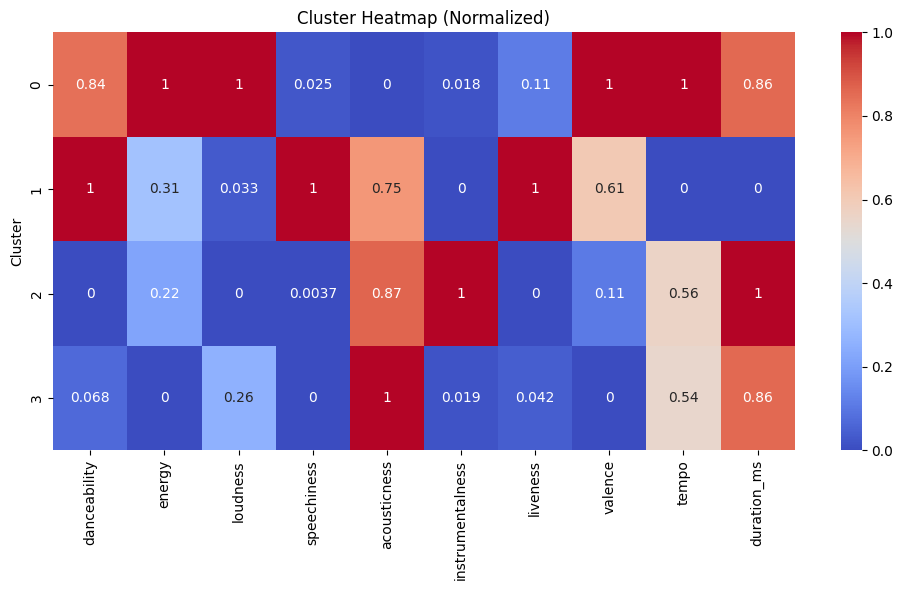


Cluster Interpretation:
Cluster 0: Party / Energetic Tracks - high energy, danceability and valence.
Cluster 1: Rap / Speech-heavy Tracks - very high speechiness.
Cluster 2: Instrumental Tracks - very high instrumentalness.
Cluster 3: Acoustic / Chill Tracks - high acousticness and low energy.

✅ PROJECT COMPLETED SUCCESSFULLY
Final output saved as amazon_music_clusters.csv
Plots saved inside outputs folder


In [ ]:
# =========================================
# AMAZON MUSIC CLUSTERING PROJECT
# =========================================

# 1. IMPORT LIBRARIES
import os
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")


# =========================================
# 2. CREATE OUTPUT FOLDER
# =========================================
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)


# =========================================
# 3. LOAD DATA
# =========================================
df = pd.read_csv("single_genre_artists.csv")

print("Original Shape:", df.shape)
print("\nColumn Names:")
print(df.columns)

print("\nData Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())


# =========================================
# 4. SAMPLE DATA
# =========================================
df = df.sample(n=5000, random_state=42)

print("\nSampled Shape:", df.shape)


# =========================================
# 5. CLEAN DATA
# =========================================
df = df.drop_duplicates()

df = df.drop(
    columns=[
        "id_songs",
        "name_song",
        "id_artists",
        "release_date",
        "genres",
        "name_artists"
    ],
    errors="ignore"
)

# =========================================
# 6. FEATURE SELECTION
# =========================================
features = [
    "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness",
    "valence", "tempo", "duration_ms"
]

X = df[features].copy()

X = X.apply(pd.to_numeric, errors="coerce")
X = X.dropna()

df = df.loc[X.index]

print("\nFinal Feature Shape:", X.shape)

print("\nSummary Statistics:")
print(X.describe())


# =========================================
# 7. EDA VISUALIZATIONS
# =========================================
X.hist(figsize=(15, 10), bins=30)
plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "feature_distributions.png"))
plt.show()

plt.figure(figsize=(10, 6))
sns.heatmap(X.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "correlation_heatmap.png"))
plt.show()


# =========================================
# 8. SCALING
# =========================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nScaling completed successfully.")


# =========================================
# 9. ELBOW METHOD
# =========================================
inertia = []
k_range = range(2, 11)

for k in k_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "elbow_method.png"))
plt.show()


# =========================================
# 10. SILHOUETTE SCORE
# =========================================
sil_scores = []

for k in k_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels,
        sample_size=500,
        random_state=42
    )
    sil_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(k_range, sil_scores, marker="o")
plt.title("Silhouette Score")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "silhouette_score.png"))
plt.show()

print("\nSilhouette Scores:")
for k, score in zip(k_range, sil_scores):
    print(f"K={k}: {score}")


# =========================================
# 11. FINAL KMEANS MODEL
# =========================================
k = 4

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

print("\nCluster Counts:")
print(df["Cluster"].value_counts().sort_index())
cluster_counts = df["Cluster"].value_counts().sort_index()

plt.figure(figsize=(7,5))
cluster_counts.plot(kind="bar")
plt.title("Cluster Size Distribution")
plt.xlabel("Cluster")
plt.ylabel("Number of Songs")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "cluster_distribution.png"))
plt.show()


# =========================================
# 12. MODEL EVALUATION
# =========================================
sil = silhouette_score(
    X_scaled,
    df["Cluster"],
    sample_size=500,
    random_state=42
)

db = davies_bouldin_score(X_scaled, df["Cluster"])

print("\nFinal Model Evaluation:")
print("Silhouette Score:", sil)
print("Davies-Bouldin Score:", db)


# =========================================
# 13. PCA VISUALIZATION
# =========================================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df["PCA1"] = X_pca[:, 0]
df["PCA2"] = X_pca[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="Set2"
)
plt.title("Clusters Visualization using PCA")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "pca_cluster_visualization.png"))
plt.show()


# =========================================
# 14. CLUSTER ANALYSIS
# =========================================
cluster_summary = df.groupby("Cluster")[features].mean()

print("\nCluster Summary:")
print(cluster_summary)

cluster_summary.to_csv(
    os.path.join(OUTPUT_DIR, "cluster_summary.csv")
)


# =========================================
# 15. NORMALIZED CLUSTER HEATMAP
# =========================================
cluster_summary_scaled = (
    cluster_summary - cluster_summary.min()
) / (cluster_summary.max() - cluster_summary.min())

plt.figure(figsize=(10, 6))
sns.heatmap(
    cluster_summary_scaled,
    annot=True,
    cmap="coolwarm"
)
plt.title("Cluster Heatmap (Normalized)")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "cluster_heatmap.png"))
plt.show()


# =========================================
# 16. CLUSTER INTERPRETATION
# =========================================
cluster_info = {
    0: "Party / Energetic Tracks - high energy, danceability and valence.",
    1: "Rap / Speech-heavy Tracks - very high speechiness.",
    2: "Instrumental Tracks - very high instrumentalness.",
    3: "Acoustic / Chill Tracks - high acousticness and low energy."
}

print("\nCluster Interpretation:")
for cluster, meaning in cluster_info.items():
    print(f"Cluster {cluster}: {meaning}")


# =========================================
# 17. SAVE FINAL OUTPUT
# =========================================
df.to_csv("amazon_music_clusters.csv", index=False)

print("\n✅ PROJECT COMPLETED SUCCESSFULLY")
print("Final output saved as amazon_music_clusters.csv")
print("Plots saved inside outputs folder")